Dataframe dimensions: (541909, 8)


,Column Type,Null Values (Count),Null Values (%)
InvoiceNo,object,0,0.000000
StockCode,object,0,0.000000
Description,object,1454,0.268311
Quantity,int64,0,0.000000
InvoiceDate,datetime64[ns],0,0.000000
UnitPrice,float64,0,0.000000
CustomerID,object,135080,24.926694
Country,object,0,0.000000


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


Dataframe dimensions after dropping nulls: (406829, 8)


,Column Type,Null Values (Count),Null Values (%)
InvoiceNo,object,0,0.0
StockCode,object,0,0.0
Description,object,0,0.0
Quantity,int64,0,0.0
InvoiceDate,datetime64[ns],0,0.0
UnitPrice,float64,0,0.0
CustomerID,object,0,0.0
Country,object,0,0.0


Duplicated entries: 5225
Number of countries in the dataframe: 37


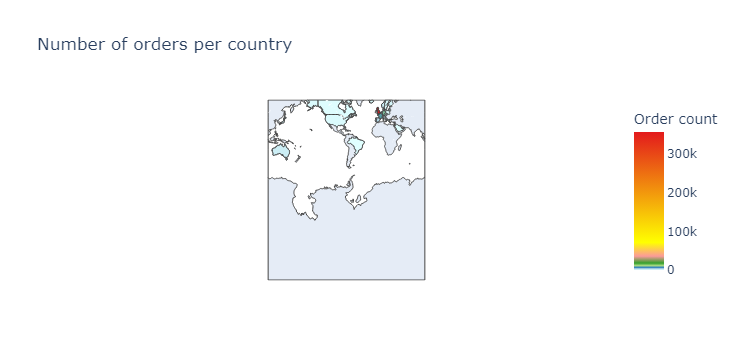

,Products,Transactions,Customers
0,3684,22190,4372


Number of canceled orders: 3654/22190 (0.16%)
CustomerID        14527
Quantity             -1
StockCode             D
Description    Discount
UnitPrice          27.5
Name: 141, dtype: object
--------------> HYPOTHESIS NOT FULFILLED
Entries to remove: 7521
Doubtful entries: 1226


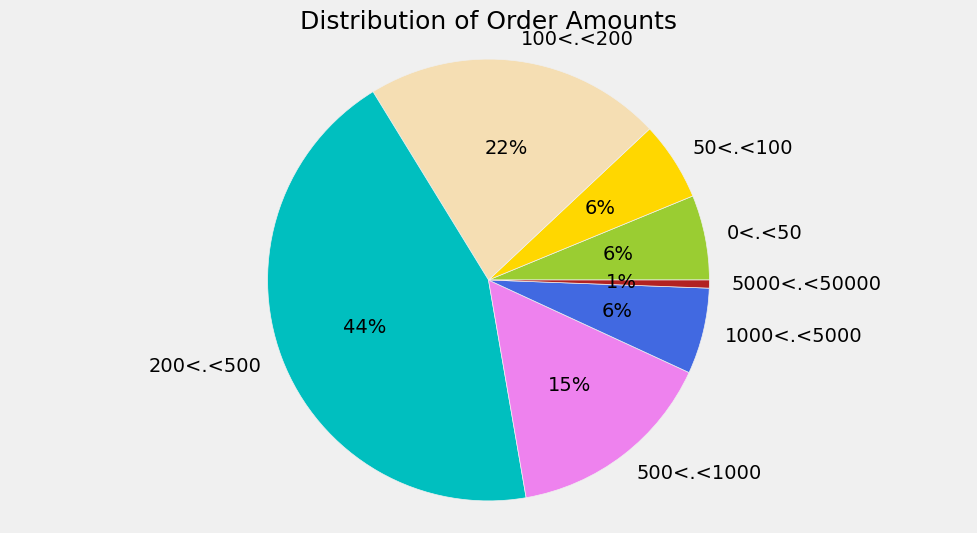

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode

# Khởi tạo môi trường cho Plotly
init_notebook_mode(connected=True)
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')

# Đọc dữ liệu
df_initial = pd.read_csv('data.csv', encoding="ISO-8859-1",
                         dtype={'CustomerID': str, 'InvoiceNo': str})
print(f'Dataframe dimensions: {df_initial.shape}')

# Chuyển đổi định dạng ngày
df_initial['InvoiceDate'] = pd.to_datetime(df_initial['InvoiceDate'])

# Thông tin về các cột
info_summary = pd.DataFrame({
    'Column Type': df_initial.dtypes,
    'Null Values (Count)': df_initial.isnull().sum(),
    'Null Values (%)': df_initial.isnull().sum() / df_initial.shape[0] * 100
})
display(info_summary)

# Hiển thị 5 dòng đầu tiên
display(df_initial.head())

# Loại bỏ các dòng có CustomerID null
df_initial.dropna(subset=['CustomerID'], inplace=True)
print(f'Dataframe dimensions after dropping nulls: {df_initial.shape}')

# Thông tin lại về các cột
info_summary = pd.DataFrame({
    'Column Type': df_initial.dtypes,
    'Null Values (Count)': df_initial.isnull().sum(),
    'Null Values (%)': df_initial.isnull().sum() / df_initial.shape[0] * 100
})
display(info_summary)

# Kiểm tra và loại bỏ duplicates
print(f'Duplicated entries: {df_initial.duplicated().sum()}')
df_initial.drop_duplicates(inplace=True)

# Phân tích theo quốc gia
countries = df_initial['Country'].value_counts()
print(f'Number of countries in the dataframe: {len(countries)}')

# Tạo biểu đồ choropleth
data = dict(
    type='choropleth',
    locations=countries.index,
    locationmode='country names',
    z=countries.values,
    text=countries.index,
    colorbar={'title': 'Order count'},
    colorscale=[
        [0, 'rgb(224,255,255)'],
        [0.01, 'rgb(166,206,227)'], 
        [0.02, 'rgb(31,120,180)'],
        [0.03, 'rgb(178,223,138)'], 
        [0.05, 'rgb(51,160,44)'],
        [0.10, 'rgb(251,154,153)'],
        [0.20, 'rgb(255,255,0)'],
        [1, 'rgb(227,26,28)']
    ],
    reversescale=False
)
layout = dict(title='Number of orders per country', geo=dict(showframe=True, projection={'type': 'mercator'}))
choromap = go.Figure(data=[data], layout=layout)
iplot(choromap, validate=False)

# Thống kê số lượng sản phẩm, giao dịch, khách hàng
stats_summary = pd.DataFrame({
    'Products': [len(df_initial['StockCode'].value_counts())],
    'Transactions': [len(df_initial['InvoiceNo'].value_counts())],
    'Customers': [len(df_initial['CustomerID'].value_counts())]
})
display(stats_summary)

# Phân tích giỏ hàng
basket_summary = df_initial.groupby(['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
basket_summary.rename(columns={'InvoiceDate': 'Number of Products'}, inplace=True)

# Xác định các đơn hàng bị hủy
basket_summary['Order Canceled'] = basket_summary['InvoiceNo'].apply(lambda x: int('C' in x))
canceled_count = basket_summary['Order Canceled'].sum()
total_orders = basket_summary.shape[0]
print(f'Number of canceled orders: {canceled_count}/{total_orders} ({canceled_count / total_orders:.2f}%)')

# Kiểm tra đơn hàng và các mục liên quan
df_check = df_initial[df_initial['Quantity'] < 0][['CustomerID', 'Quantity', 'StockCode', 'Description', 'UnitPrice']]
for index, col in df_check.iterrows():
    if df_initial[(df_initial['CustomerID'] == col[0]) & (df_initial['Quantity'] == -col[1]) 
                  & (df_initial['Description'] == col[2])].shape[0] == 0: 
        print(df_check.loc[index])
        print('--------------> HYPOTHESIS NOT FULFILLED')
        break

# Xử lý dữ liệu sạch hơn
df_cleaned = df_initial.copy()
df_cleaned['QuantityCanceled'] = 0
entry_to_remove = []
doubtful_entry = []

for index, col in df_initial.iterrows():
    if col['Quantity'] > 0 or col['Description'] == 'Discount':
        continue        
    df_test = df_initial[(df_initial['CustomerID'] == col['CustomerID']) &
                         (df_initial['StockCode'] == col['StockCode']) & 
                         (df_initial['InvoiceDate'] < col['InvoiceDate']) & 
                         (df_initial['Quantity'] > 0)]
    
    if df_test.shape[0] == 0: 
        doubtful_entry.append(index)
    elif df_test.shape[0] == 1: 
        index_order = df_test.index[0]
        df_cleaned.loc[index_order, 'QuantityCanceled'] = -col['Quantity']
        entry_to_remove.append(index)        
    elif df_test.shape[0] > 1: 
        df_test.sort_index(ascending=False, inplace=True)        
        for ind, val in df_test.iterrows():
            if val['Quantity'] < -col['Quantity']:
                continue
            df_cleaned.loc[ind, 'QuantityCanceled'] = -col['Quantity']
            entry_to_remove.append(index) 
            break            

print(f"Entries to remove: {len(entry_to_remove)}")
print(f"Doubtful entries: {len(doubtful_entry)}")

# Loại bỏ các mục không hợp lệ
df_cleaned.drop(entry_to_remove + doubtful_entry, axis=0, inplace=True)

# Tính toán tổng giá trị giỏ hàng
df_cleaned['TotalPrice'] = df_cleaned['UnitPrice'] * (df_cleaned['Quantity'] - df_cleaned['QuantityCanceled'])
df_cleaned.sort_values('CustomerID', inplace=True)

# Đếm số lượng giỏ hàng theo các khoảng giá
basket_price = df_cleaned.groupby(['CustomerID', 'InvoiceNo'], as_index=False)['TotalPrice'].sum()
basket_price = basket_price[basket_price['TotalPrice'] > 0]
price_range = [0, 50, 100, 200, 500, 1000, 5000, 50000]
count_price = [basket_price[(basket_price['TotalPrice'] < price) & 
                             (basket_price['TotalPrice'] > price_range[i-1])].shape[0] for i, price in enumerate(price_range) if i != 0]

# Vẽ biểu đồ hình tròn cho số lượng đơn hàng theo khoảng giá
plt.figure(figsize=(11, 6))
colors = ['yellowgreen', 'gold', 'wheat', 'c', 'violet', 'royalblue', 'firebrick']
labels = [f'{price_range[i-1]}<.<{price}' for i, price in enumerate(price_range) if i != 0]
plt.pie(count_price, labels=labels, colors=colors, autopct='%1.0f%%', shadow=False, startangle=0)
plt.axis('equal')
plt.title("Distribution of Order Amounts", fontsize=18)
plt.show()


In [36]:
df_cleaned.shape

(392857, 10)

In [33]:
df_cleaned.to_csv('cleaned_data.csv', index=False)